# Imports & Load Data

In [10]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Load data
df = pd.read_csv('Superstore.csv', encoding='latin-1')

# First look
print(df.shape)
print(df.dtypes)
df.head()

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Data Cleaning

In [13]:
# Check for nulls
print("Null values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicates:", df.duplicated().sum())

# Fix date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Extract useful time features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')

print("\nDate range:", df['Order Date'].min(), "to", df['Order Date'].max())
print("Cleaned successfully ✅")

Null values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicates: 0

Date range: 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Cleaned successfully ✅


# EDA: Business Overview

In [16]:
# Total key metrics
print("=== BUSINESS OVERVIEW ===")
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")

# Sales by Category
print("\n=== SALES BY CATEGORY ===")
print(df.groupby('Category')[['Sales','Profit']].sum().round(2))

# Sales by Region
print("\n=== SALES BY REGION ===")
print(df.groupby('Region')[['Sales','Profit']].sum().round(2))

# Sales by Year
print("\n=== SALES BY YEAR ===")
print(df.groupby('Order Year')[['Sales','Profit']].sum().round(2))

=== BUSINESS OVERVIEW ===
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Profit Margin: 12.47%

=== SALES BY CATEGORY ===
                     Sales     Profit
Category                             
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80
Technology       836154.03  145454.95

=== SALES BY REGION ===
             Sales     Profit
Region                       
Central  501239.89   39706.36
East     678781.24   91522.78
South    391721.90   46749.43
West     725457.82  108418.45

=== SALES BY YEAR ===
                Sales    Profit
Order Year                     
2014        484247.50  49543.97
2015        470532.51  61618.60
2016        609205.60  81795.17
2017        733215.26  93439.27


# Visualization

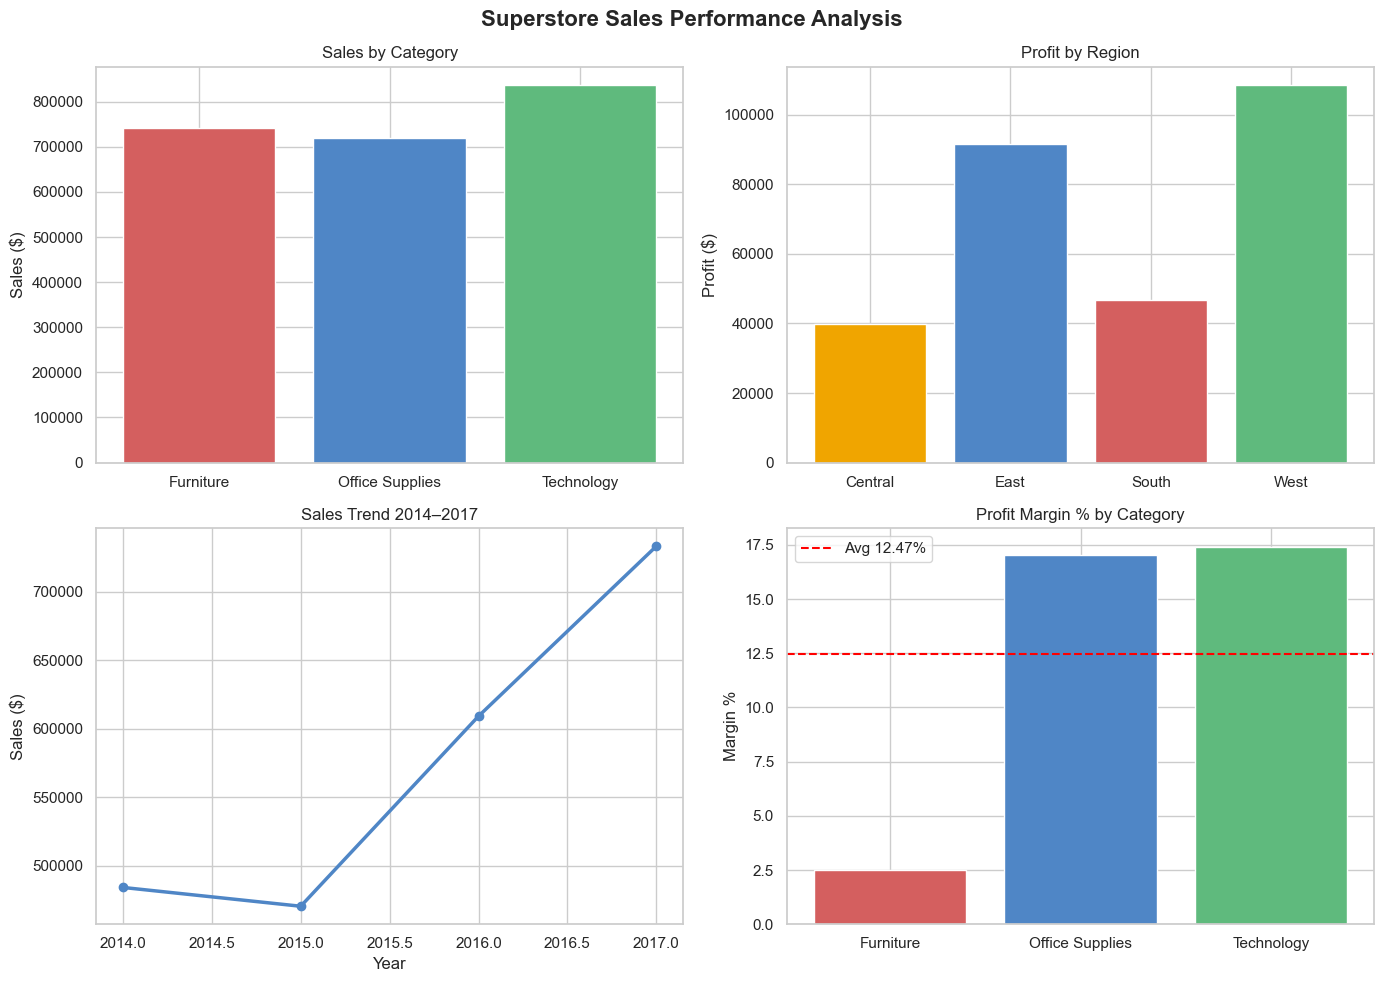

Chart saved ✅


In [21]:
# Cell 4 — Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Superstore Sales Performance Analysis', fontsize=16, fontweight='bold')

# 1. Sales by Category
axes[0,0].bar(df.groupby('Category')['Sales'].sum().index,
              df.groupby('Category')['Sales'].sum().values,
              color=['#d45f5f','#4f86c6','#5fba7d'])
axes[0,0].set_title('Sales by Category')
axes[0,0].set_ylabel('Sales ($)')

# 2. Profit by Region
axes[0,1].bar(df.groupby('Region')['Profit'].sum().index,
              df.groupby('Region')['Profit'].sum().values,
              color=['#f0a500','#4f86c6','#d45f5f','#5fba7d'])
axes[0,1].set_title('Profit by Region')
axes[0,1].set_ylabel('Profit ($)')

# 3. Sales trend by Year
yearly = df.groupby('Order Year')['Sales'].sum()
axes[1,0].plot(yearly.index, yearly.values, marker='o', 
               color='#4f86c6', linewidth=2.5)
axes[1,0].set_title('Sales Trend 2014–2017')
axes[1,0].set_ylabel('Sales ($)')
axes[1,0].set_xlabel('Year')

# 4. Profit Margin by Category
margins = df.groupby('Category').apply(
    lambda x: (x['Profit'].sum()/x['Sales'].sum()*100), 
    include_groups=False).round(2)
axes[1,1].bar(margins.index, margins.values,
              color=['#d45f5f','#4f86c6','#5fba7d'])
axes[1,1].set_title('Profit Margin % by Category')
axes[1,1].set_ylabel('Margin %')
axes[1,1].axhline(y=12.47, color='red', linestyle='--', label='Avg 12.47%')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\Pabuddha\OneDrive\Desktop\sales-dashboard-project\Visuals\sales_overview.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved ✅")

# Hypothesis Testing

In [24]:
# Cell 5 — Hypothesis Testing
# Question: Do discounts significantly reduce profit margin?

print("=== HYPOTHESIS TEST: DISCOUNT IMPACT ON PROFIT ===\n")

# Split into two groups
discounted = df[df['Discount'] > 0]['Profit']
non_discounted = df[df['Discount'] == 0]['Profit']

print(f"Discounted orders — Mean Profit: ${discounted.mean():.2f} | Count: {len(discounted)}")
print(f"Non-discounted orders — Mean Profit: ${non_discounted.mean():.2f} | Count: {len(non_discounted)}")

# T-Test
t_stat, p_value = stats.ttest_ind(discounted, non_discounted)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n✅ RESULT: Statistically significant difference (p < 0.05)")
    print("Discounts DO significantly impact profit — reject null hypothesis")
else:
    print("\n❌ RESULT: No statistically significant difference (p >= 0.05)")
    print("Cannot conclude discounts impact profit")

# Discount breakdown
print("\n=== PROFIT BY DISCOUNT LEVEL ===")
df['Discount Band'] = pd.cut(df['Discount'], 
                              bins=[-0.1, 0, 0.2, 0.4, 0.6, 0.9],
                              labels=['No Discount','0-20%','20-40%','40-60%','60-90%'])
print(df.groupby('Discount Band', observed=True)['Profit'].mean().round(2))

=== HYPOTHESIS TEST: DISCOUNT IMPACT ON PROFIT ===

Discounted orders — Mean Profit: $-6.66 | Count: 5196
Non-discounted orders — Mean Profit: $66.90 | Count: 4798

t-statistic: -15.8786
p-value: 0.000000

✅ RESULT: Statistically significant difference (p < 0.05)
Discounts DO significantly impact profit — reject null hypothesis

=== PROFIT BY DISCOUNT LEVEL ===
Discount Band
No Discount     66.90
0-20%           26.50
20-40%         -77.86
40-60%        -134.62
60-90%         -98.35
Name: Profit, dtype: float64


# Linear Regression

=== LINEAR REGRESSION: DISCOUNT vs PROFIT ===

R² Score: -0.7241
RMSE: $289.12

Coefficients:
  Discount: -208.8587
  Sales: 0.2593
  Quantity: -6.5120
  Intercept: 29.4756


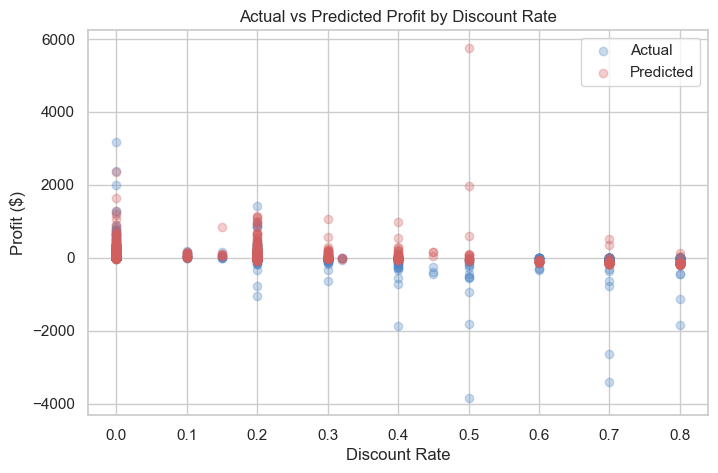


Regression chart saved ✅


In [27]:
# Cell 6 — Linear Regression: Discount vs Profit
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

print("=== LINEAR REGRESSION: DISCOUNT vs PROFIT ===\n")

# Features and target
X = df[['Discount', 'Sales', 'Quantity']]
y = df['Profit']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.4f}")
print(f"RMSE: ${rmse:.2f}")
print(f"\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {model.intercept_:.4f}")

# Visualise
plt.figure(figsize=(8,5))
plt.scatter(X_test['Discount'], y_test, alpha=0.3, label='Actual', color='#4f86c6')
plt.scatter(X_test['Discount'], y_pred, alpha=0.3, label='Predicted', color='#d45f5f')
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.title('Actual vs Predicted Profit by Discount Rate')
plt.legend()
plt.savefig(r'C:\Users\Pabuddha\OneDrive\Desktop\sales-dashboard-project\Visuals\regression.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("\nRegression chart saved ✅")

# Seasonal Trend Analysis

=== SEASONAL SALES TREND ===



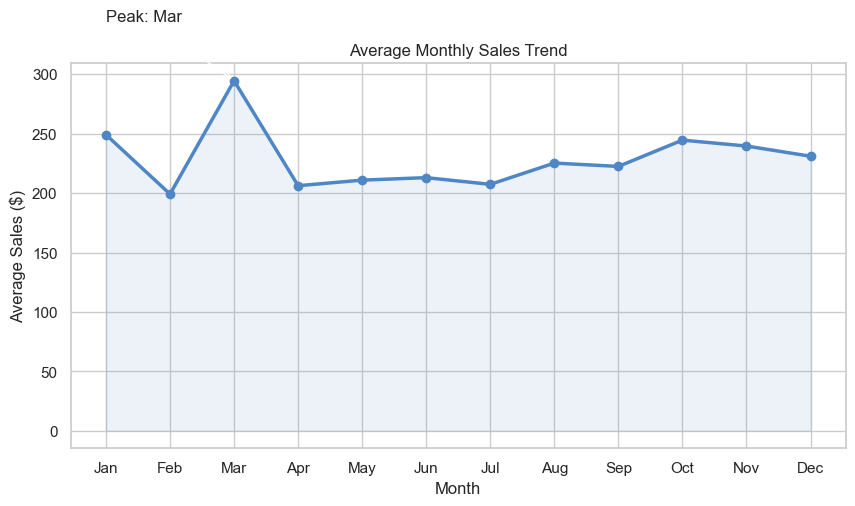

Peak sales month: Mar
Lowest sales month: Feb

Monthly breakdown:
Order Month
1     249.15
2     199.17
3     294.55
4     206.23
5     210.92
6     213.00
7     207.38
8     225.27
9     222.45
10    244.59
11    239.61
12    231.03
Name: Sales, dtype: float64


In [30]:
# Cell 7 — Seasonal Trend Analysis
print("=== SEASONAL SALES TREND ===\n")

# Monthly sales average across all years
monthly = df.groupby('Order Month')['Sales'].mean().round(2)
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10,5))
plt.plot(range(1,13), monthly.values, marker='o', 
         color='#4f86c6', linewidth=2.5)
plt.xticks(range(1,13), month_names)
plt.title('Average Monthly Sales Trend')
plt.ylabel('Average Sales ($)')
plt.xlabel('Month')
plt.fill_between(range(1,13), monthly.values, alpha=0.1, color='#4f86c6')

# Annotate peak month
peak_month = monthly.idxmax()
plt.annotate(f'Peak: {month_names[peak_month-1]}',
             xy=(peak_month, monthly[peak_month]),
             xytext=(peak_month-2, monthly[peak_month]+50),
             arrowprops=dict(arrowstyle='->'))

plt.savefig(r'C:\Users\Pabuddha\OneDrive\Desktop\sales-dashboard-project\Visuals\seasonal_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak sales month: {month_names[peak_month-1]}")
print(f"Lowest sales month: {month_names[monthly.idxmin()-1]}")
print(f"\nMonthly breakdown:\n{monthly}")